In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcol
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib import ticker
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

plt.style.use('./presentation.mplstyle')

In [2]:
gls = sim(exgrp_fields=['GroupFirstSub'],exsub_fields=['SubhaloMass','SubhaloStellarPhotometrics'])
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [3]:
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5,hfloor=10):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,thresh,floor)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
    back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
    back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    x200 = [[],[],[]]

    all_gal_pos =  gls.sub.SubhaloPos[all_gal,:]
    massive_gal_pos = gls.sub.SubhaloPos[massive_gal,:] 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        blh = (np.where(j==back_gal)[0])[0]
        
        if gls.hst.group_m200[lh]>=hfloor:
                #dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                if gls.sub.mst[j]<9.5: dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                else: dist,ind = np.sort(rall)[1:6],np.argsort(rall)[1:6]
                    
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
                          
                dhost[2].append(dist[0])
                llt[2].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                x200[2].append(back_dz0[blh]/gls.hst.Group_R_Crit200[back_host[blh]])
                    
                #dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                dist0 = np.sort(rall)[:5]
                dist0 *= dconv
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

        #all_gal = np.delete(all_gal,np.where(all_gal==j)[0])

    all_gal,massive_gal = np.array(list(set(all_gal)-set(back_gal))), np.array(list(set(massive_gal)-set(back_gal)))
    all_gal_tree =  KDTree(gls.sub.SubhaloPos[all_gal,:]) 
    massive_gal_tree = KDTree(gls.sub.SubhaloPos[massive_gal,:]) 
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[all_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        #print(gls.hst.group_m200[lh])
        if gls.hst.group_m200[lh]>=hfloor:
            dw_mem = all_gal[np.where(host_mem==i)[0]]

            stellar_sort = np.argsort(gls.sub.mst[dw_mem])
            cen = dw_mem[stellar_sort[-1]]

            #r = wrap_dist_1n(gls.sub.SubhaloPos[cen,:],gls.hst.GroupPos[lh,:])
            if len(dw_mem)>=1:
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[cen,:])
                if gls.sub.mst[j]<9.5: dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                else: dist,ind = np.sort(rall)[1:6],np.argsort(rall)[1:6]                
                ind = massive_gal[ind]  
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])

                dhost[0].append(dist[0])
                llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                x200[0].append(0)
                
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist0 = np.sort(rall)[:5]
                dist0 *= dconv
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                        if gls.sub.mst[j]<9.5: dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                        else: dist,ind = np.sort(rall)[1:6],np.argsort(rall)[1:6] 

                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
    
                        dhost[1].append(dist[0])
                        llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
                        x200[1].append(wrap_dist_0n(gls.sub.SubhaloPos[j,:],gls.hst.GroupPos[lh,:])/gls.hst.Group_R_Crit200[lh])

    
                        rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist0 = np.sort(rall)[:5]
                        dist0 *= dconv
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost,x200

In [4]:
sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

llt,llh,llg,llr,dhost,x200 = samp_selc(hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']

1494 10829
-8.346120696830761 -0.17679571397785238
1494 10829
12323 0.098584


/var/folders/h6/wvvht_j93kdd56hj5zln7l_h0vlgf3/T/ipykernel_46270/1780237328.py:76: RuntimeWarning: divide by zero encountered in log10
  llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)


[5910, 5175, 1257]


In [5]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
x200_a = np.array([t for i in range(3) for t in x200[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
m200_a = gls.hst.group_m200[llh_a]
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)

ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)
Nll = len(llh_a)

In [6]:
host_bins = [np.where(m200_a<11.5)[0],np.where(m200_a>=11.5)[0]]
#host_bins = [np.where((m200_a<11.5)|((m200_a>=11.5)&(x200_a>=1)))[0],np.where((m200_a>=11.5)&(x200_a<1))[0]]
bin_cols = ['teal','firebrick']

dw_samp = np.where((m200_a<11.5)&(mst_a<9.5))[0]
print(len(np.unique(llh_a[dw_samp])))


5449


In [7]:
print(min(dhost_a[host_bins[1]]),max(dhost_a[host_bins[1]]))

0.0 5.563663582100093


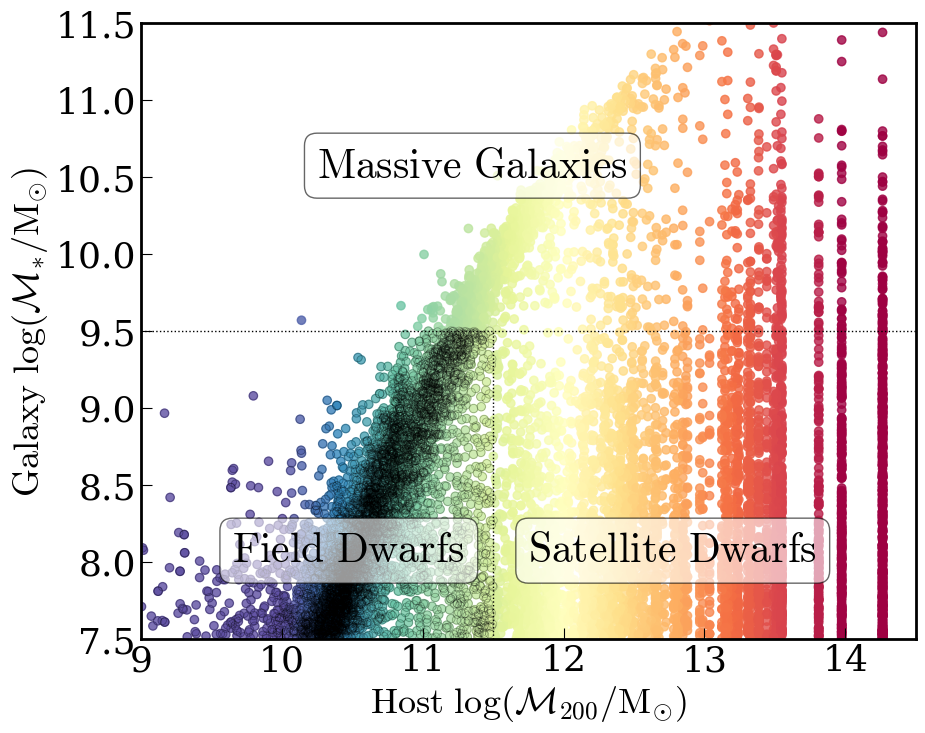

In [7]:
fig,ax=plt.subplots(figsize=(10,8))

ax.scatter(m200_a,mst_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.8)
ax.scatter(m200_a[dw_samp],mst_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.3)

ax.set_xlim((9,14.5))
ax.set_ylim((7.5,11.5))
ax.axhline(9.5,ls=':',lw=1,color='black')
ax.axvline(11.5,ymax=0.5,ls=':',lw=1,color='black')

ax.text(10.25,10.5,r'$Massive\ Galaxies$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(11.75,8,r'$Satellite\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(9.65,8,r'$Field\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))

ax.set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax.set_ylabel(r'$Galaxy\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=26)
ax.set_rasterized(True)
plt.savefig('hostM_subhaloM.pdf',bbox_inches='tight')

6304
6038


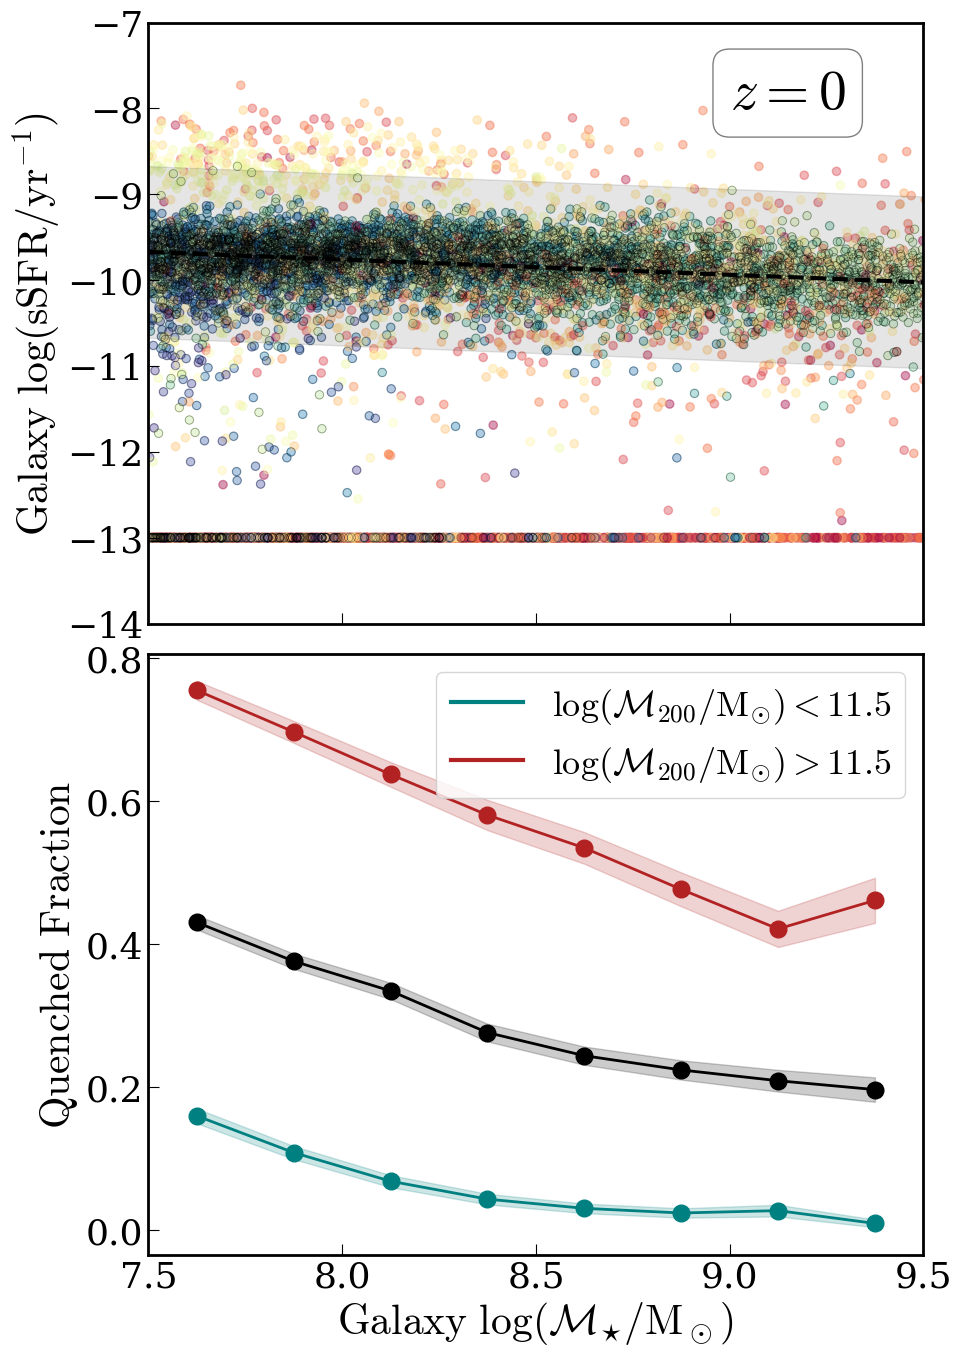

In [10]:
fig,ax=plt.subplots(2,1,figsize=(10,16),sharex=True)

mst_bins = np.linspace(7.5,9.5,9)
mst_bw = 0.5*(mst_bins[1]-mst_bins[0])

Nbtsp = 1000

ssfr_a[ssfr_a<-13] = -13

ax[0].scatter(mst_a,ssfr_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.4)
ax[0].scatter(mst_a[dw_samp],ssfr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.4)

sfr_seq = sfms_intercept + sfms_slope*mst_bins
ax[0].plot(mst_bins,sfr_seq,color='black',ls='--',lw=3)
ax[0].fill_between(mst_bins,sfr_seq-1,sfr_seq+1,color='black',alpha=0.1)

boot_qnc = np.zeros((Nbtsp,8))
for m in range(Nbtsp):
        boot = npr.choice(range(Nll),size=Nll,replace=True)

        mst_b = [mst_a[i] for i in boot]
        ssfr_b = [ssfr_a[i] for i in boot]
        qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

        bin_qnc, bin_edg, bin_n = sts.binned_statistic(mst_b,qnc_b,statistic='mean', bins=mst_bins)
        boot_qnc[m,:] = bin_qnc
        
boot_val = np.mean(boot_qnc,axis=0)
boot_err = np.std(boot_qnc,axis=0,ddof=1)

ax[1].plot(mst_bins[:-1]+mst_bw,boot_val,lw=2,marker='o',color='black',markersize=12)
ax[1].fill_between(mst_bins[:-1]+mst_bw,boot_val-boot_err,boot_val+boot_err,color='black',alpha=0.2)


for j in range(2):
    print(len(host_bins[j]))
    boot_qnc = np.zeros((Nbtsp,8))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
    
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(mst_b,qnc_b,statistic='mean', bins=mst_bins)
            boot_qnc[m,:] = bin_qnc
            
    boot_val = np.mean(boot_qnc,axis=0)
    boot_err = np.std(boot_qnc,axis=0,ddof=1)

    ax[1].plot(mst_bins[:-1]+mst_bw,boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
    ax[1].fill_between(mst_bins[:-1]+mst_bw,boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


ax[0].set_ylim((-14,-7))
ax[0].set_xlim((7.5,9.5))

#ax[0].set_xlabel(r'$log(\mathcal{M}_{\star}/ M_\odot)$',fontsize=30)
ax[0].set_ylabel(r'$Galaxy\ log(sSFR/yr^{-1})$',fontsize=30)
ax[0].text(9,-8,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))

ax[1].set_ylabel(r'$Quenched\ Fraction$',fontsize=30)
ax[1].set_xlabel(r'$Galaxy\ log(\mathcal{M}_{\star}/ M_\odot)$',fontsize=30)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[1],custom_lines,[r'$log(\mathcal{M}_{200}/M_{\odot})<11.5$',r'$log(\mathcal{M}_{200}/M_{\odot})>11.5$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[1].add_artist(leg)

#fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=12),cmap=mcm.RdGy), ax=ax[0], orientation='vertical',fraction=2.2,label=r'$log(\mathcal{M}_{200}/M_{\odot})$')
ax[0].set_rasterized(True)
plt.subplots_adjust(hspace=0.05)
plt.savefig('tidal_mst.pdf',bbox_inches='tight')
#plt.savefig('starburst_sm.pdf',bbox_inches='tight')

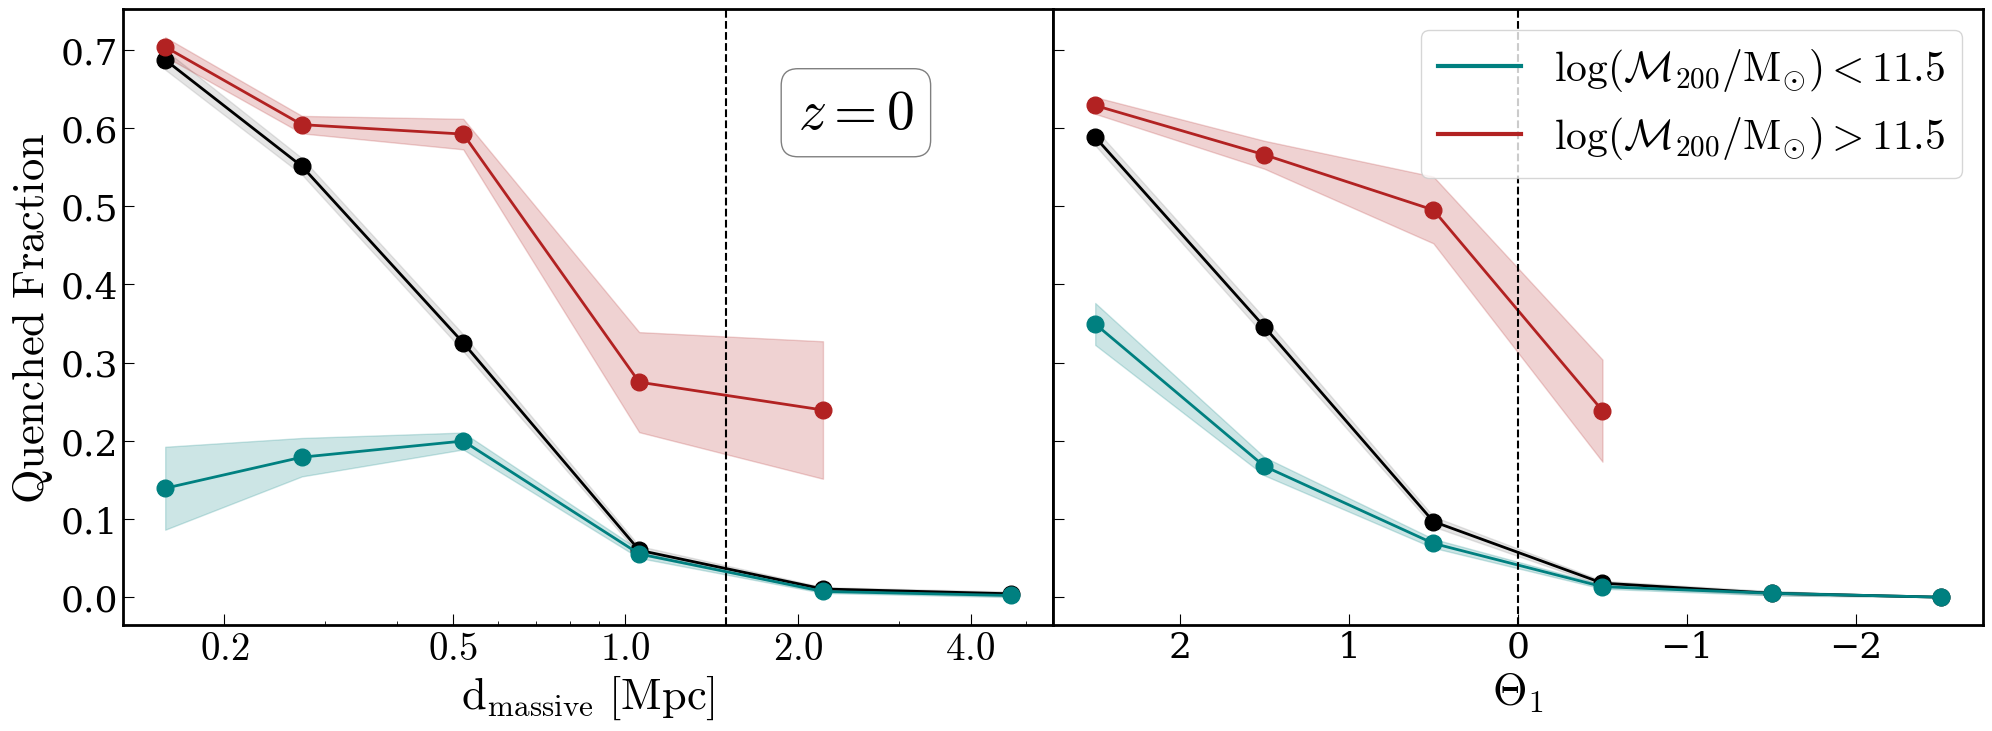

In [12]:
fig,ax=plt.subplots(1,2,figsize=(24,8),sharey=True)

tracer_bins = [np.logspace(np.log10(0.1),np.log10(10),7),np.linspace(-3,3,7)]
tracer_bw = [0.5*(tb[1]-tb[0]) for tb in tracer_bins]

Nbtsp = 1000

'''boot_qncall, boot_qfeall = np.zeros((2,Nbtsp,20)),np.zeros((2,Nbtsp,20))
qnc_c = np.zeros(2)

slc = llg_a[host_isol[0]]        
qnc_c[0] = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc) 
            
slc = llg_a[host_isol[1]]
qnc_c[1] = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc) 
print(qnc_c[0],qnc_c[1])'''
boot_qnc = np.zeros((2,Nbtsp,6))
for m in range(Nbtsp):
            boot = npr.choice(range(Nll),size=Nll,replace=True)

            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
    
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
        
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins[0])
            boot_qnc[0,m,:] = bin_qnc
            #boot_qfeall[0,m] = (bin_qnc-qnc_c[0])/(1-qnc_c[0])     
        
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins[1])
            boot_qnc[1,m,:] = bin_qnc
            #boot_qfeall[1,m] = (bin_qnc-qnc_c[1])/(1-qnc_c[1])

for j in range(2):
    boot_val=np.mean(boot_qnc[j,:,:],axis=0)
    boot_err=np.std(boot_qnc[j,:,:],axis=0,ddof=1)
    
    ax[j].plot(tracer_bins[j][:-1]+tracer_bw[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[j].fill_between(tracer_bins[j][:-1]+tracer_bw[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)
'''
    boot_val=np.mean(boot_qfeall[j,:,:],axis=0)
    boot_err=np.std(boot_qfeall[j,:,:],axis=0,ddof=1)
    
    ax[1,j].plot(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[1,j].fill_between(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)

'''

for j in range(2):
    boot_qnc = np.zeros((2,Nbtsp,6))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
    
            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins[0])
            boot_qnc[0,m,:] = bin_qnc

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins[1])
            boot_qnc[1,m,:] = bin_qnc
        
    for k in range(2):
        boot_val = np.mean(boot_qnc[k,:,:],axis=0)
        boot_err = np.std(boot_qnc[k,:,:],axis=0,ddof=1)
    
        ax[k].plot(tracer_bins[k][:-1]+tracer_bw[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[k].fill_between(tracer_bins[k][:-1]+tracer_bw[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)
'''        
        boot_val = np.mean(boot_qfe[k,:,:],axis=0)
        boot_err = np.std(boot_qfe[k,:,:],axis=0,ddof=1)
    
        ax[1,k].plot(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[1,k].fill_between(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

for k in range(2):
    ax[k].axhline(0.2,color='black',ls='-.')
'''
ax[0].set_xscale('log')
ax[0].axvline(1.5,color='black',ls='--')
ax[1].axvline(0,color='black',ls='--')
ax[1].invert_xaxis()
xticks = [0.2,0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
ax[0].set_xticks(xticks, labels=xlabels,fontsize=28)

ax[0].set_ylabel(r'$Quenched\ Fraction$',fontsize=32)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)
ax[0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=32)
ax[1].set_xlabel(r'$\Theta_1$',fontsize=32)
ax[0].text(2,0.6,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))


custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[1],custom_lines,[r'$log(\mathcal{M}_{200}/ M_{\odot})< 11.5$',r'$log(\mathcal{M}_{200}/ M_{\odot})> 11.5$'],loc='upper right',fontsize=30,framealpha=0.8,frameon=True)
ax[1].add_artist(leg)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('quenchtracer_geha12.pdf',bbox_inches='tight')


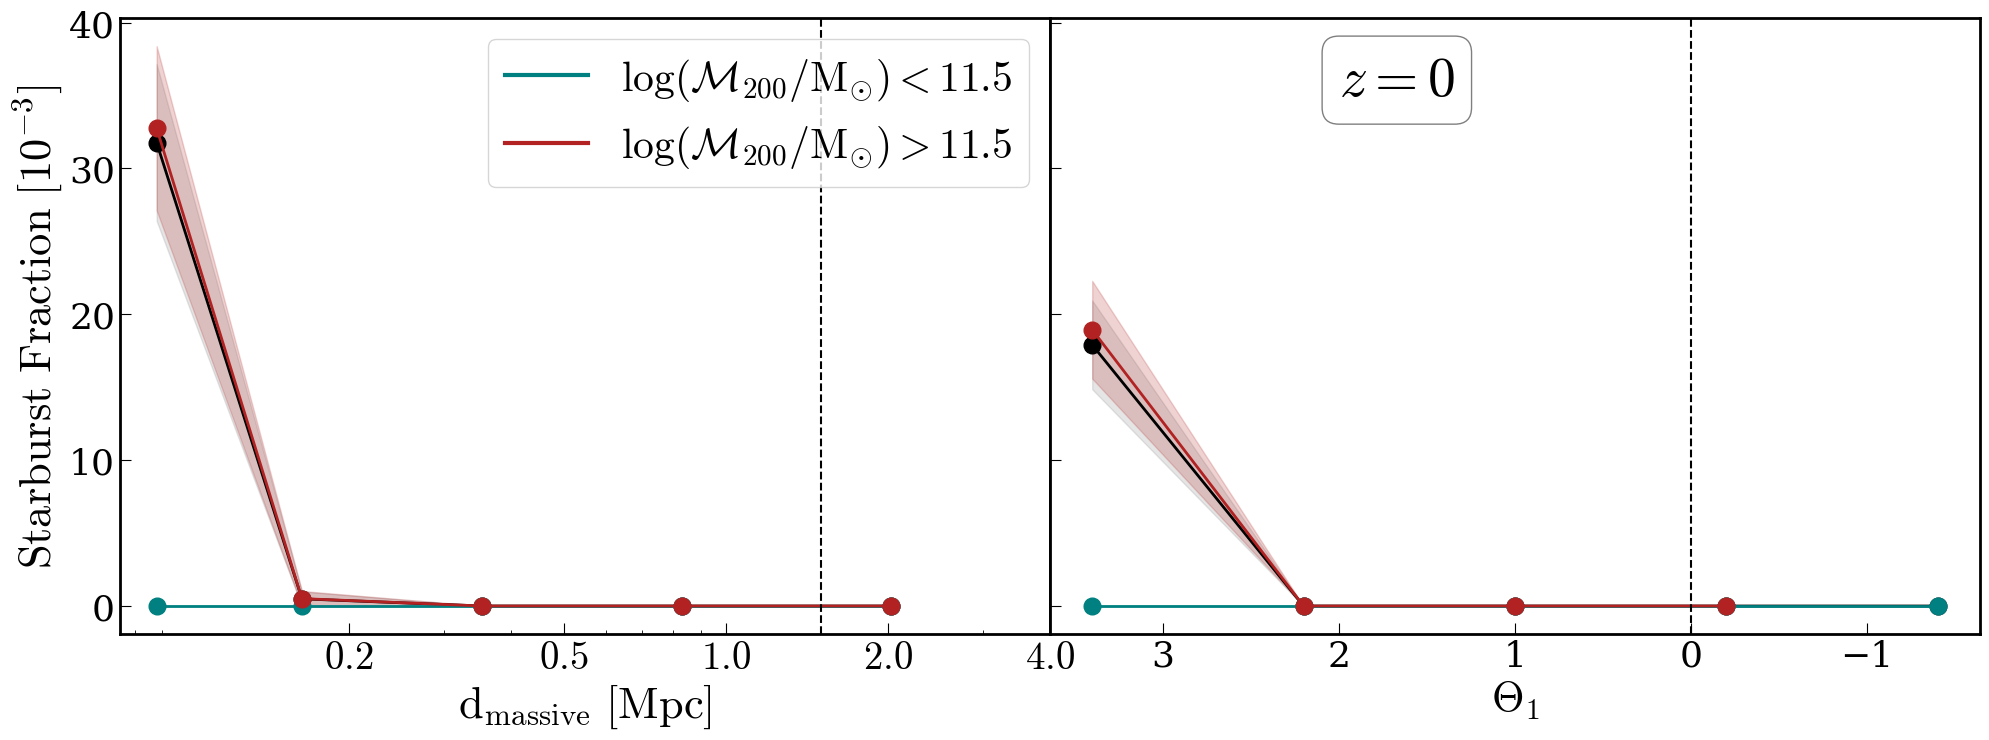

In [16]:
fig,ax=plt.subplots(1,2,figsize=(24,8),sharey=True)

#dsfr_bins = np.linspace(0,2,9)
#dsfr_bw = 0.5*(dsfr_bins[1]-dsfr_bins[0])
Nbtsp = 1000

tracer_bins = [np.logspace(np.log10(0.05),np.log10(5),6),np.linspace(-2,4,6)]
tracer_bw = [0.5*(tb[1]-tb[0]) for tb in tracer_bins]

boot_qnc = np.zeros((2,Nbtsp,5))
for m in range(Nbtsp):
            boot = npr.choice(range(Nll),size=Nll,replace=True)

            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
        
            dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
            qnc_b = np.heaviside(ssfr_b-(sfms_intercept +1 + sfms_slope*np.array(mst_b)),1)
    
            bin_all, bin_edg,_ = sts.binned_statistic(dhost_b,qnc_b,bins=tracer_bins[0],statistic='mean')
            boot_qnc[0,m,:] = bin_all

            bin_all, bin_edg,_ = sts.binned_statistic(llt_b,qnc_b,bins=tracer_bins[1],statistic='mean')
            boot_qnc[1,m,:] = bin_all

for j in range(2):
    boot_val=1e3*np.mean(boot_qnc[j,:,:],axis=0)
    boot_err=1e3*np.std(boot_qnc[j,:,:],axis=0,ddof=1)
    
    ax[j].plot(tracer_bins[j][:-1]+tracer_bw[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[j].fill_between(tracer_bins[j][:-1]+tracer_bw[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)

#tracer_bins1 = [np.logspace(np.log10(0.2),np.log10(12),5),np.linspace(-2,2,5)]
#tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

for j in range(2):
    boot_qnc = np.zeros((2,Nbtsp,5))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
            dhost_b = [dhost_a[i] for i in boot]
            llt_b = np.array([llt_a[i] for i in boot])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [mst_a[i] for i in boot]
            ssfr_b = [ssfr_a[i] for i in boot]
        
            dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
            qnc_b = np.heaviside(ssfr_b-(sfms_intercept +1 + sfms_slope*np.array(mst_b)),1)
    
            bin_all, bin_edg,_ = sts.binned_statistic(dhost_b,qnc_b,bins=tracer_bins[0],statistic='mean')
            boot_qnc[0,m,:] = bin_all

            bin_all, bin_edg,_ = sts.binned_statistic(llt_b,qnc_b,bins=tracer_bins[1],statistic='mean')
            boot_qnc[1,m,:] = bin_all

    boot_val = np.mean(boot_qnc,axis=0)
    boot_err = np.std(boot_qnc,axis=0,ddof=1)
        
    for k in range(2):
        boot_val = 1e3*np.mean(boot_qnc[k,:,:],axis=0)
        boot_err = 1e3*np.std(boot_qnc[k,:,:],axis=0,ddof=1)
    
        ax[k].plot(tracer_bins[k][:-1]+tracer_bw[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[k].fill_between(tracer_bins[k][:-1]+tracer_bw[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

ax[0].set_xscale('log')
ax[0].axvline(1.5,color='black',ls='--')
ax[1].axvline(0,color='black',ls='--')
ax[1].invert_xaxis()
#ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:d}"))
xticks = [0.2,0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
ax[0].set_xticks(xticks, labels=xlabels,fontsize=28)

ax[0].set_ylabel(r'$Starburst\ Fraction\ [10^{-3}]$',fontsize=32)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)
ax[0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=32)
ax[1].set_xlabel(r'$\Theta_1$',fontsize=30)
ax[1].text(2,35,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[0],custom_lines,[r'$log(\mathcal{M}_{200}/ M_{\odot})< 11.5$',r'$log(\mathcal{M}_{200}/ M_{\odot})> 11.5$'],loc='best',fontsize=30,framealpha=0.8,frameon=True)
ax[0].add_artist(leg)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('starbursttracer_geha12.pdf',bbox_inches='tight')        
            

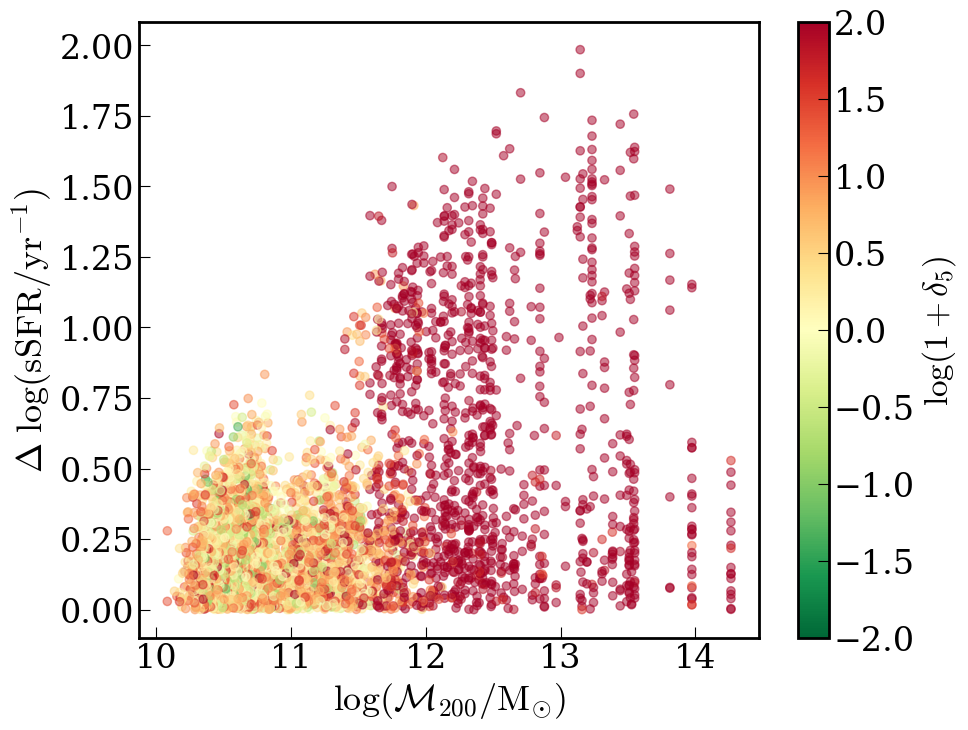

In [23]:
fig,ax=plt.subplots(figsize=(10,8))
        
dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
strbst = np.where(dsfms_a>0)[0]

ax.scatter(m200_a[strbst],dsfms_a[strbst],c=llr_a[strbst],cmap=mcm.RdYlGn_r,vmin=-2,vmax=2,alpha=0.5)

ax.set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax.set_ylabel(r'$\Delta\ log(sSFR/yr^{-1})$',fontsize=26)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-2, vmax=2),cmap=mcm.RdYlGn_r), ax=ax, orientation='vertical',label=r'$log(1+\delta_5)$')


#ax.set_yscale('log')
plt.savefig('delssfr_starburst.pdf',bbox_inches='tight')

0.014672168729940394 0.0427426536064114


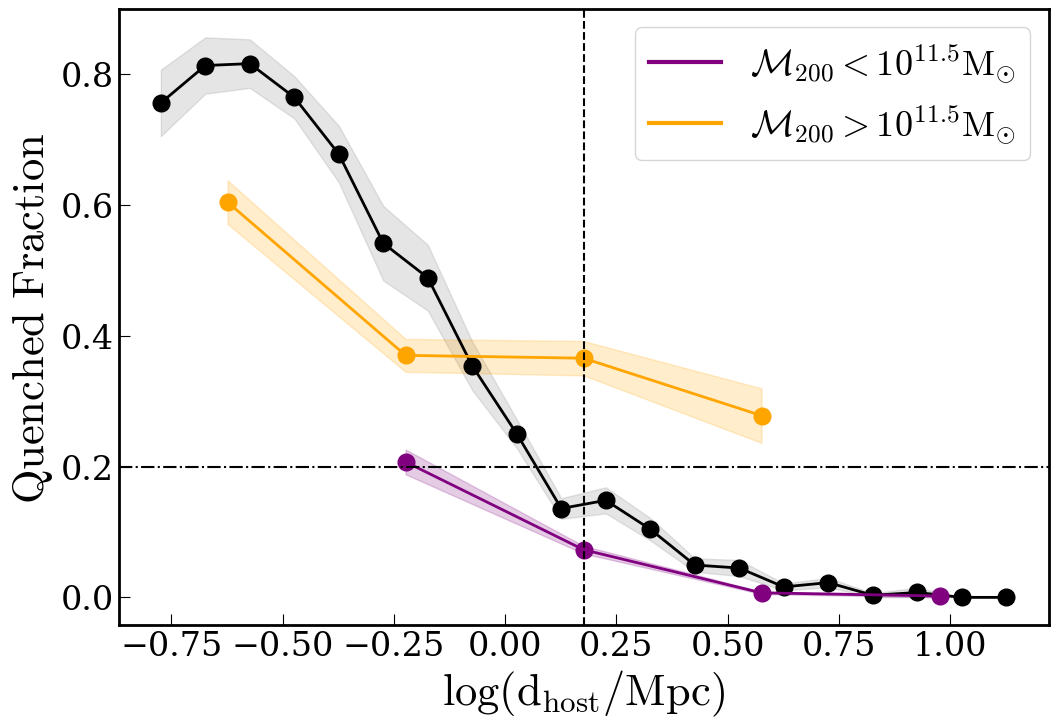

In [71]:
fig,ax=plt.subplots(figsize=(12,8),sharey=True)

tracer_bins0 = [np.linspace(np.log10(0.15),np.log10(15),21),np.linspace(-5,3,21),np.linspace(10,12,21)]
tracer_bw0 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins0]

Nbtsp = 1000

boot_qncall, boot_qfeall = np.zeros((2,Nbtsp,20)),np.zeros((2,Nbtsp,20))
qnc_c = np.zeros(2)

slc = llg_a[host_isol[0]]        
qnc_c[0] = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc) 
            
slc = llg_a[host_isol[1]]
qnc_c[1] = np.sum(1- np.heaviside(gls.sub.ssfr[slc]-(sfms_intercept -1 + sfms_slope*gls.sub.mst[slc]),1))/len(slc) 
print(qnc_c[0],qnc_c[1])

for m in range(Nbtsp):
            boot = npr.choice(range(Nll),size=Nll,replace=True)

            dhost_b = np.log10([d for i in boot for d in dhost[i]])
            llt_b = np.array([t for i in boot for t in llt[i]])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
        
            mst_b = [m for i in boot for m in gls.sub.mst[llg[i]]]
            ssfr_b = [s for i in boot for s in gls.sub.ssfr[llg[i]]]
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
        
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins0[0])
            boot_qncall[0,m,:] = bin_qnc
            #boot_qfeall[0,m] = (bin_qnc-qnc_c[0])/(1-qnc_c[0])     
        
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins0[1])
            boot_qncall[1,m,:] = bin_qnc
            #boot_qfeall[1,m] = (bin_qnc-qnc_c[1])/(1-qnc_c[1])

for j in range(1):
    boot_val=np.mean(boot_qncall[j,:,:],axis=0)
    boot_err=np.std(boot_qncall[j,:,:],axis=0,ddof=1)
    
    ax.plot(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax.fill_between(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)
'''
    boot_val=np.mean(boot_qfeall[j,:,:],axis=0)
    boot_err=np.std(boot_qfeall[j,:,:],axis=0,ddof=1)
    
    ax[1,j].plot(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val,lw=2,marker='o',color='black',markersize=12)
    ax[1,j].fill_between(tracer_bins0[j][:-1]+tracer_bw0[j],boot_val-boot_err,boot_val+boot_err,color='gray',alpha=0.2)

'''
tracer_bins1 = [np.linspace(np.log10(0.5),np.log10(15),6),np.linspace(-5,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

for j in range(2):
    boot_qnc = np.zeros((2,Nbtsp,5))
    for m in range(Nbtsp):
            boot = npr.choice(host_bins[j],size=len(host_bins[j]),replace=True)
    
            dhost_b = np.log10([d for i in boot for d in dhost[i]])
            llt_b = np.array([t for i in boot for t in llt[i]])
            #llh_b = np.array([llh[i] for i in boot for m in range(llm[i])])
    
            mst_b = [m for i in boot for m in gls.sub.mst[llg[i]]]
            ssfr_b = [s for i in boot for s in gls.sub.ssfr[llg[i]]]
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[0,m,:] = bin_qnc

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[1,m,:] = bin_qnc
        
    for k in range(1):
        boot_val = np.mean(boot_qnc[k,:,:],axis=0)
        boot_err = np.std(boot_qnc[k,:,:],axis=0,ddof=1)
    
        ax.plot(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax.fill_between(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)
'''        
        boot_val = np.mean(boot_qfe[k,:,:],axis=0)
        boot_err = np.std(boot_qfe[k,:,:],axis=0,ddof=1)
    
        ax[1,k].plot(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val,lw=2,marker='o',color=bin_cols[j],markersize=12)
        ax[1,k].fill_between(tracer_bins1[k][:-1]+tracer_bw1[k],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)
'''
ax.axhline(0.2,color='black',ls='-.')

ax.axvline(np.log10(1.5),color='black',ls='--')

ax.set_ylabel(r'$Quenched\ Fraction$',fontsize=32)
ax.set_xlabel(r'$log(d_{host}/ Mpc)$',fontsize=32)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax,custom_lines,[r'$\mathcal{M}_{200}< 10^{11.5} M_{\odot}$',r'$\mathcal{M}_{200} >10^{11.5} M_{\odot}$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax.add_artist(leg)

#plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('KITPqt_geha12.pdf',bbox_inches='tight')


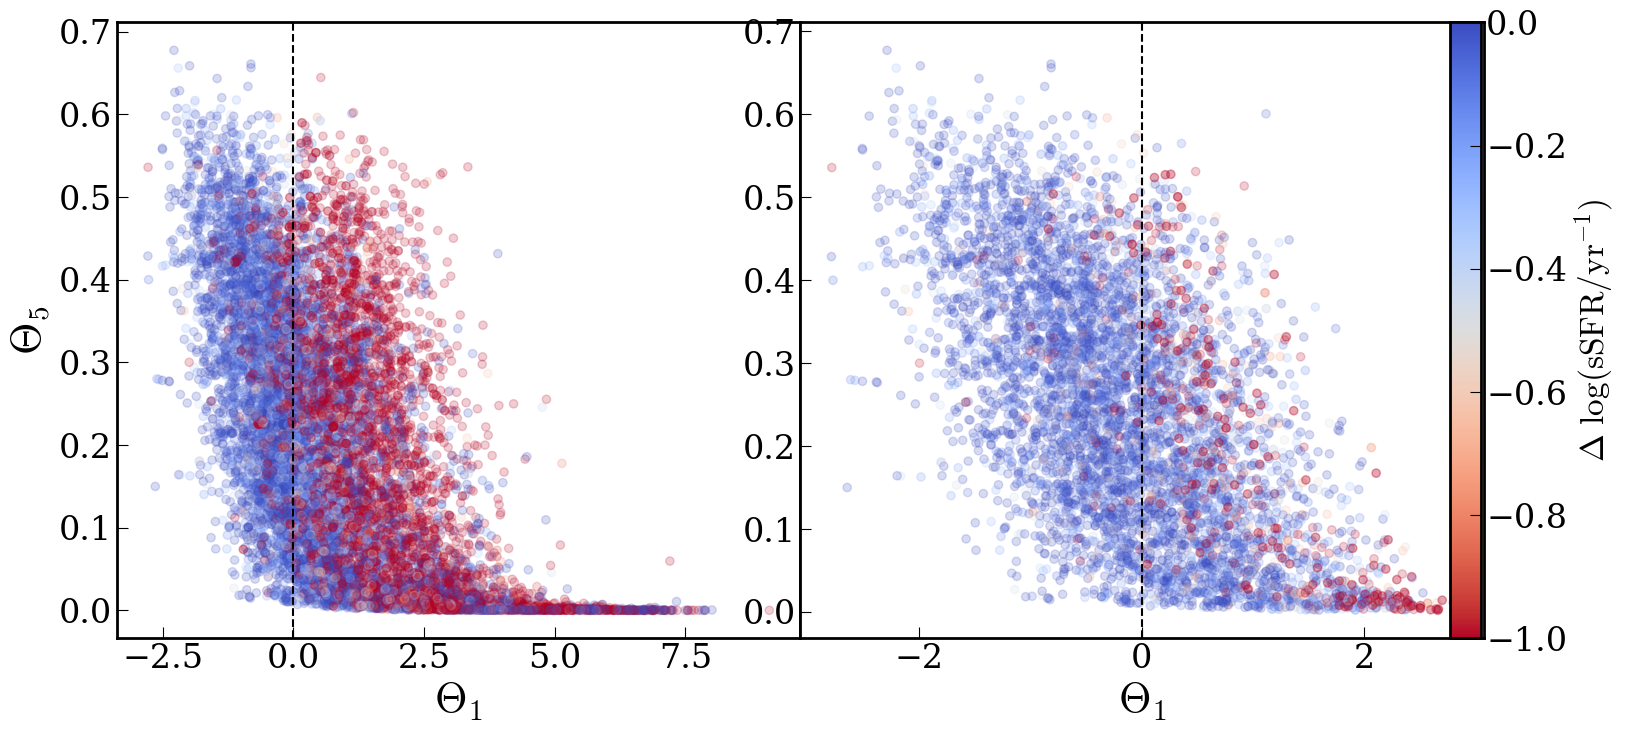

In [30]:
fig,ax=plt.subplots(1,3,figsize=(18,8),width_ratios=[0.49,0.49,0.02])

dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))

ax[0].scatter(llt_a,llt5_a-llt_a,marker='o',c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.2)
ax[1].scatter(llt_a[dw_samp],llt5_a[dw_samp]-llt_a[dw_samp],marker='o',c=dsfms_a[dw_samp],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.2)

ax[0].set_ylabel(r'$\Theta_5$',fontsize=30)

ax[0].axvline(0,color='black',ls='--')
ax[1].axvline(0,color='black',ls='--')
ax[1].set_xlabel(r'$\Theta_1$',fontsize=30)
ax[0].set_xlabel(r'$\Theta_1$',fontsize=30)
ax[2].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[2], orientation='vertical',fraction=2.2,label=r'$\Delta\ log(sSFR/yr^{-1})$')
ax[0].set_rasterized(True)
ax[1].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('tidal_mst.pdf',bbox_inches='tight')

In [72]:
back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
back_gal = np.genfromtxt('backsplash.txt',usecols=1,dtype='int')
back_dist = np.genfromtxt('backsplash.txt',usecols=2)

Nbsg = len(back_gal)
print(Nbsg)

bklg,llg_int,bkg_int = np.intersect1d(llg_a, back_gal, return_indices=True)
print(bklg)

2186
[    60     65     66 ... 901466 902203 904826]


In [37]:
dconv = 1.428571429e-3
x_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - 25
y_a = np.array([y for i in range(3) for y in gls.sub.SubhaloPos[llg[i],1]])*dconv - 25
z_a = np.array([z for i in range(3) for z in gls.sub.SubhaloPos[llg[i],2]])*dconv - 25
#x_b = np.array([gls.hst.GroupPos[llh[i],0] for i in range(Nll)])*dconv - 25
#y_b = np.array([gls.hst.GroupPos[llh[i],1] for i in range(Nll)])*dconv - 25
#z_b = np.array([gls.hst.GroupPos[llh[i],2] for i in range(Nll)])*dconv - 25

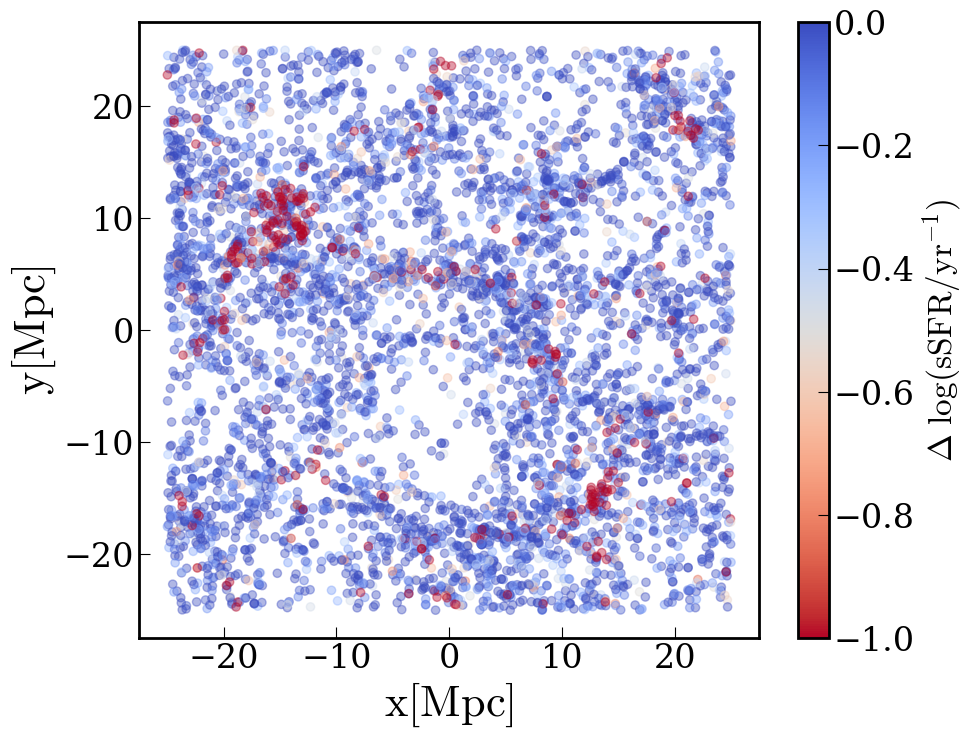

In [38]:
fig,ax=plt.subplots(figsize=(10,8))

dw_samp = np.where(m200_a<11.5)[0]
ms_samp = np.where(m200_a>=11.5)[0]
dsfms_a = ssfr_a[dw_samp]-(sfms_intercept + sfms_slope*np.array(mst_a[dw_samp]))

ax.scatter(x_a[dw_samp],y_a[dw_samp],marker='o',c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.4)
#ax.scatter(x_a[llg_int],y_a[llg_int],c='none',edgecolors='black',linewidth=2,alpha=0.8) 
#ax.scatter(x_a[ms_samp],y_a[ms_samp],marker='o',c='yellow',s=2,alpha=0.6)

ax.set_xlabel(r'$x[Mpc]$',fontsize=32)
ax.set_ylabel(r'$y[Mpc]$',fontsize=32)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax, orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax.set_rasterized(True)
plt.savefig('KITP_xymap.pdf',bbox_inches='tight')

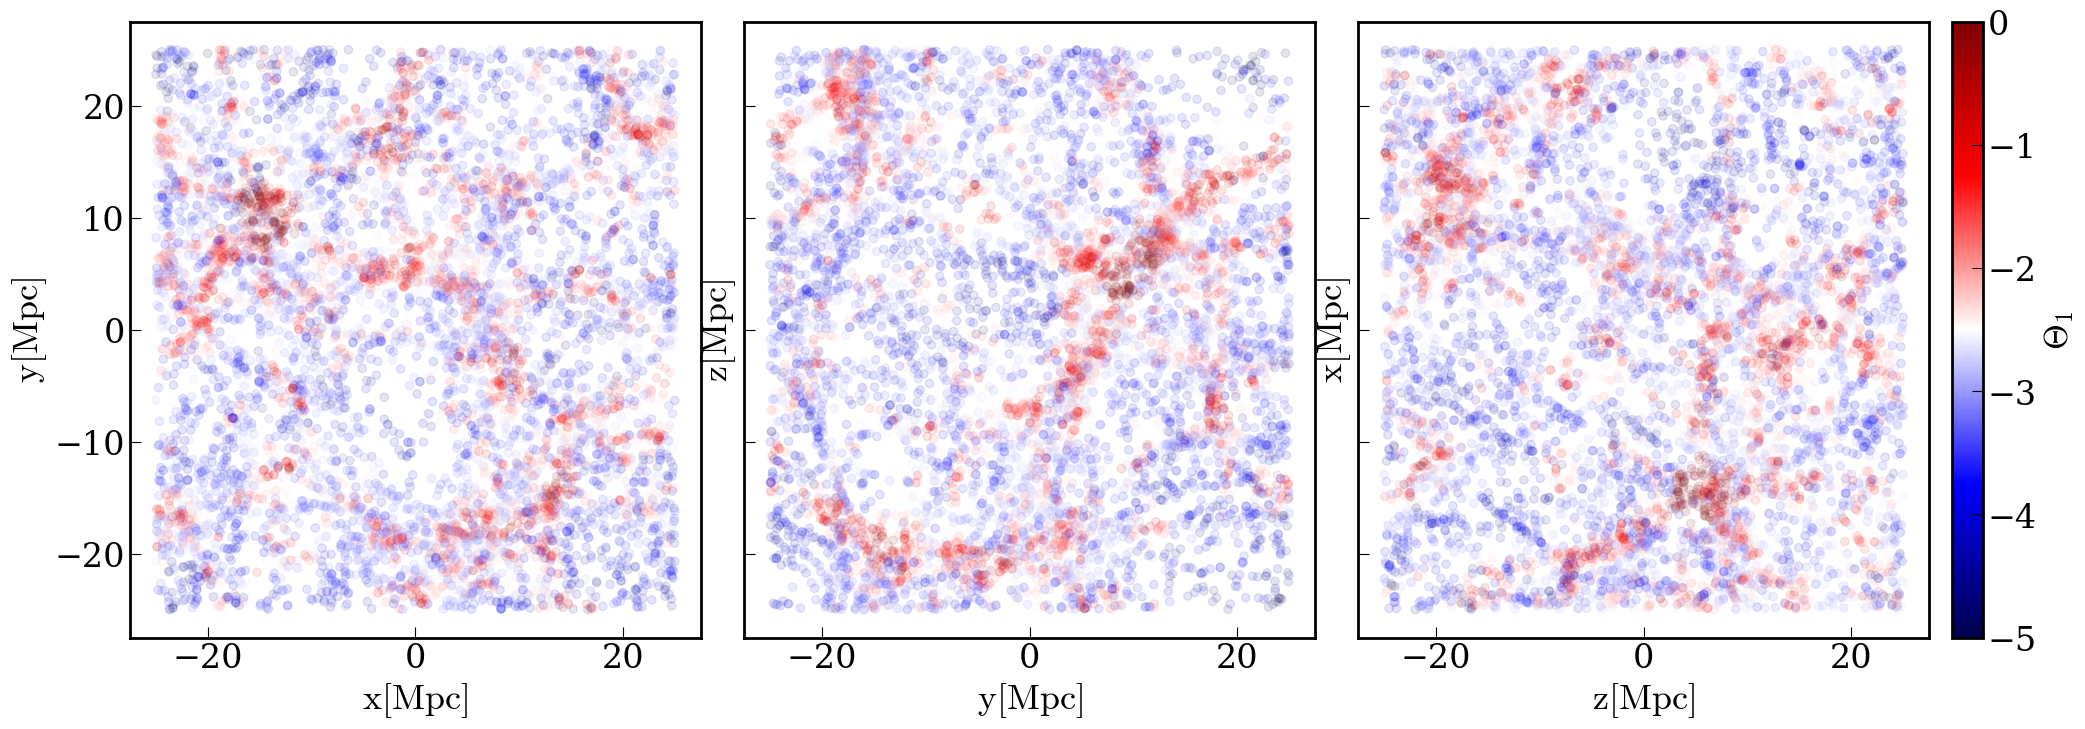

In [93]:
fig,ax=plt.subplots(1,4,figsize=(24,8),sharey=True,width_ratios=[0.33,0.33,0.33,0.01])

ax[0].scatter(x_a,y_a,marker='o',c=llt_a,cmap=mcm.seismic,vmin=-5,vmax=0,alpha=0.1)
ax[1].scatter(y_a,z_a,marker='o',c=llt_a,cmap=mcm.seismic,vmin=-5,vmax=0,alpha=0.1)
ax[2].scatter(z_a,x_a,marker='o',c=llt_a,cmap=mcm.seismic,vmin=-5,vmax=0,alpha=0.1)

for j in range(3):
    ax[0].set_rasterized(True)

ax[3].set_axis_off()

ax[0].set_xlabel(r'$x[Mpc]$'fontsize=30)
ax[0].set_ylabel(r'$y[Mpc]$'fontsize=30)
ax[1].set_xlabel(r'$y[Mpc]$'fontsize=30)
ax[1].set_ylabel(r'$z[Mpc]$'fontsize=30)
ax[2].set_xlabel(r'$z[Mpc]$'fontsize=30)
ax[2].set_ylabel(r'$x[Mpc]$'fontsize=30)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-5, vmax=0),cmap=mcm.seismic), ax=ax[3], orientation='vertical',fraction=2.2,label=r'$\Theta_1$',pad=0.0)

plt.subplots_adjust(wspace=0.1)
plt.savefig('tidal_map.pdf',bbox_inches='tight')

In [48]:
H0 = cosmo.H(0)
rho0 = cosmo.critical_density(0)
conv = ((u.g).to(u.solMass))/((u.cm).to(u.Mpc)**3)

print(H0,rho0,c.G)
print(-np.log10(rho0.value*conv))

H0 = 100*(u.km).to(u.Mpc)/u.s
rho0 = 3*H0*H0/(8*np.pi*c.G)
conv  = ((u.kg).to(u.solMass))/((u.m).to(u.Mpc)**3)

print(H0,rho0,c.G)
print(-np.log10(rho0.value*conv))


67.74 km / (Mpc s) 8.619160453017515e-30 g / cm3   Name   = Gravitational constant
  Value  = 6.6743e-11
  Uncertainty  = 1.5e-15
  Unit  = m3 / (kg s2)
  Reference = CODATA 2018
-11.105010690854513
3.2407792894443648e-18 1 / s 1.8783416169331674e-26 kg / m3   Name   = Gravitational constant
  Value  = 6.6743e-11
  Uncertainty  = 1.5e-15
  Unit  = m3 / (kg s2)
  Reference = CODATA 2018
-11.44332030623729


In [37]:
host_isol = [np.where((dhost_a>1.5)&(m200_a<11.5))[0],np.where((llt_a<0)&(m200_a<11.5))[0]]
print(len(host_isol[0]),len(host_isol[1]))

comm, isol0, isol1 = np.intersect1d(host_isol[0],host_isol[1], return_indices=True)
print(len(comm),len(isol0),len(isol1))


4633 3466
3408 3408 3408
